# 空转分群

- coder: yangdong, yinzhanhao
- date: 2605
- [github](https://github.com/edward130603/BayesSpace) [tutorial](https://www.ezstatconsulting.com/BayesSpace/articles/BayesSpace.html)
- image: SuperCells scRNA analysis Packages V3

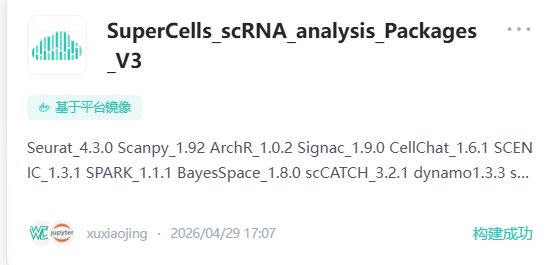

In [1]:
suppressPackageStartupMessages({
    library(SingleCellExperiment)
    library(ggplot2)
    library(BayesSpace)
    library(Seurat)
    library(cowplot)
    library(RColorBrewer)
    library(stringr)
    library(Seurat)
    library(SeuratDisk)
})

In [7]:
rds_paths <- c(
    "/data/work/m1.rds",
    "/data/work/m2.rds"
)
sample_key <- 'sample'

In [4]:
temp0 <- readRDS(rds_paths[1])
if (length(rds_paths) != 1){
    for (i in rds_paths[2:length(rds_paths)]){
        tmp <- readRDS(i)
        temp0 <- merge(temp0, tmp)
    }
}

In [8]:
print(temp0); print(head(temp0@meta.data))
print(unique(temp0@meta.data[[sample_key]]))

An object of class Seurat 
22045 features across 5952 samples within 1 assay 
Active assay: Spatial (22045 features, 0 variable features)
 2 layers present: counts, data
                      X_index nCount_Spatial nFeature_Spatial orig.ident
60902636269820 60902636269820             18               11     sample
60902636269840 60902636269840             27               20     sample
60902636269860 60902636269860             29               23     sample
60902636269880 60902636269880             12               11     sample
60902636269900 60902636269900              9                8     sample
60902636269920 60902636269920             47               24     sample
               percent.mito sample     x     y
60902636269820            0     m1 14180 12540
60902636269840            0     m1 14180 12560
60902636269860            0     m1 14180 12580
60902636269880            0     m1 14180 12600
60902636269900            0     m1 14180 12620
60902636269920            0     m1 14

In [9]:
#dir <- '/data/work/Ol_stem_new_lasso/Ol.seurat.integrated.RDS'
#sample <- 'tl4'
log_method <- 'sct'
clus <- 13

In [10]:
temp0.list <- SplitObject(temp0, split.by = sample_key)

In [15]:
seurat_spatialObj <- temp0.list[[1]]
sample <- 'm1'

In [11]:
temp0.list

$m1
An object of class Seurat 
22045 features across 1891 samples within 1 assay 
Active assay: Spatial (22045 features, 0 variable features)
 2 layers present: counts, data

$m2
An object of class Seurat 
22045 features across 4061 samples within 1 assay 
Active assay: Spatial (22045 features, 0 variable features)
 2 layers present: counts, data


- what is qplot?
- 

In [16]:
seurat_spatialObj

An object of class Seurat 
22045 features across 1891 samples within 1 assay 
Active assay: Spatial (22045 features, 0 variable features)
 2 layers present: counts, data

In [18]:
# # seurat_spatialObj@images
# # 使用stereopy的h5ad2rds转换后是没有@images的
# seurat_spatialObj@meta.data$row = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$x
# seurat_spatialObj@meta.data$col = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$y

list()

## Log normalization or other normalization

In [20]:
if(log_method=='log'){
    seurat_spatialObj <- NormalizeData(seurat_spatialObj)
    seurat_spatialObj <- FindVariableFeatures(seurat_spatialObj)
    seurat_spatialObj <- ScaleData(seurat_spatialObj)
    sce <- as.SingleCellExperiment(seurat_spatialObj)
    sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
} else if(log_method=='sct'){
    seurat_spatialObj=SCTransform(seurat_spatialObj, assay = "Spatial", verbose = FALSE)
    sce <- as.SingleCellExperiment(seurat_spatialObj, assay="SCT")
    sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
}

In [21]:
sce

class: SingleCellExperiment 
dim: 3525 1891 
metadata(1): BayesSpace.data
assays(2): counts logcounts
rownames(3525): CP000013 CP000017 ... MT052048 MT052057
rowData names(1): is.HVG
colnames(1891): 60902636269820 60902636269840 ... 65283502912080
  65283502912100
colData names(11): X_index nCount_Spatial ... nFeature_SCT ident
reducedDimNames(1): PCA
mainExpName: SCT
altExpNames(0):

## cluster

In [ ]:
# determine the optimal number of clusters
sce <- qTune(sce, qs=seq(2, 20), platform="ST", d=13)
qPlot(sce)

Neighbors were identified for 0 out of 1891 spots.

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...



In [29]:
sce$row <- sce$x; sce$col <- sce$y

In [30]:
# fast version
# note: spatialCluster要求数据必须在meta.data包含col和row
# row (x coordinates) and col (y coordinates)
sce <- spatialCluster(sce, q=clus, platform="ST", d=8,
                    init.method="mclust", model="t", gamma=2,
                    nrep=3000, burn.in=100,
                    save.chain=TRUE)

Neighbors were identified for 0 out of 1891 spots.

Fitting model...

Calculating labels using iterations 100 through 3000.



## plot

In [32]:
pale<-c(brewer.pal(12,"Set3"),brewer.pal(9,"Set1"),brewer.pal(8,"Dark2"),brewer.pal(12,"Paired"))
temp <- as.data.frame(colData(sce))
head(temp)

,X_index,nCount_Spatial,nFeature_Spatial,orig.ident,percent.mito,sample,x,y,nCount_SCT,nFeature_SCT,ident,row,col,cluster.init,spatial.cluster
,<chr>,<int>,<int>,<chr>,<dbl>,<chr>,<int>,<int>,<dbl>,<int>,<fct>,<int>,<int>,<dbl>,<dbl>
60902636269820,60902636269820,18,11,sample,0,m1,14180,12540,24,9,AnnData,14180,12540,1,1
60902636269840,60902636269840,27,20,sample,0,m1,14180,12560,26,14,AnnData,14180,12560,2,2
60902636269860,60902636269860,29,23,sample,0,m1,14180,12580,23,17,AnnData,14180,12580,2,2
60902636269880,60902636269880,12,11,sample,0,m1,14180,12600,24,9,AnnData,14180,12600,2,2
60902636269900,60902636269900,9,8,sample,0,m1,14180,12620,22,7,AnnData,14180,12620,2,2
60902636269920,60902636269920,47,24,sample,0,m1,14180,12640,41,18,AnnData,14180,12640,3,3


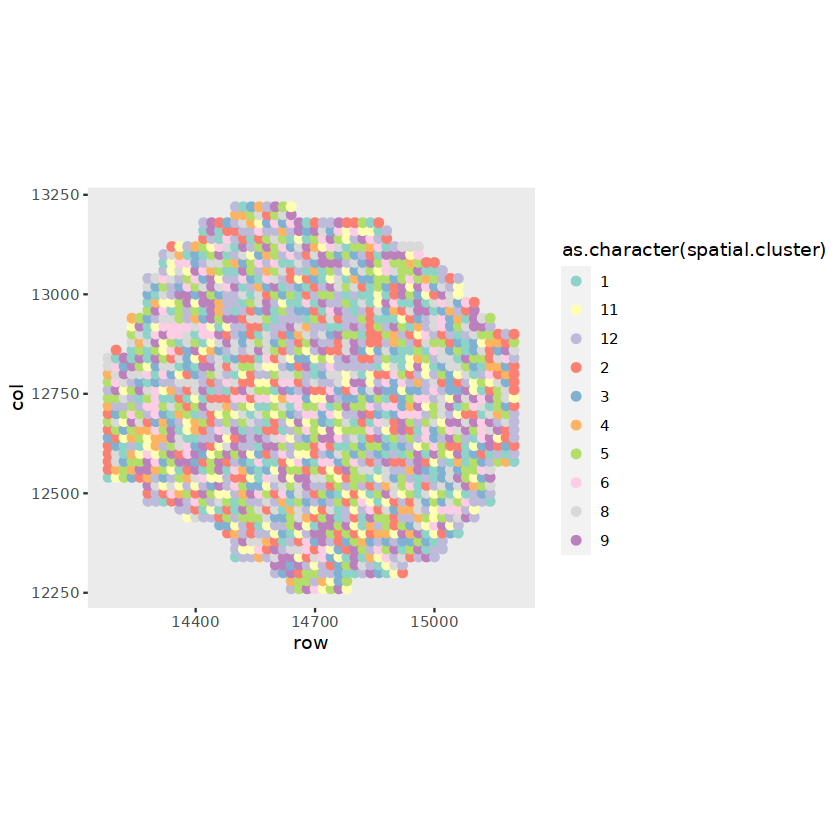

In [33]:
ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
       scale_colour_discrete(type=pale,na.value="grey")+
       theme(panel.grid=element_blank())+
       coord_fixed() 

## save as h5ad

In [ ]:
rds2h5ad <- function(){
    sce.seurat <- as.Seurat(sce, counts="counts", data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq', assay = "Spatial", coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".", log_method, ".fast.h5Seurat"), assay="Spatial", overwrite=TRUE)
    Convert(paste0(sample, ".", log_method, ".fast.h5Seurat"), dest = "h5ad", overwrite=TRUE)
}

In [ ]:
for(sample in unique(temp0@meta.data[[sample_key]])){
    seurat_spatialObj <- temp0.list[[sample]]
    set.seed(1234)
    seurat_spatialObj@meta.data$row = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$x
    seurat_spatialObj@meta.data$col = seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates$y

    # different normalization methods
    if(log_method=='log'){
        seurat_spatialObj <- NormalizeData(seurat_spatialObj)
        seurat_spatialObj <- FindVariableFeatures(seurat_spatialObj)
        seurat_spatialObj <- ScaleData(seurat_spatialObj)
        sce <- as.SingleCellExperiment(seurat_spatialObj)
        sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
    } else if(log_method=='sct'){
        seurat_spatialObj=SCTransform(seurat_spatialObj, assay = "Spatial", verbose = FALSE)
        sce <- as.SingleCellExperiment(seurat_spatialObj,assay="SCT")
        sce <- spatialPreprocess(sce, platform="ST", n.PCs=30, n.HVGs=3000, log.normalize=F)
    }

    # determine the optimal number of clusters
    sce <- qTune(sce, qs=seq(2, 20), platform="ST", d=13)
    qPlot(sce)

    # fast version
    sce <- spatialCluster(sce, q=clus, platform="ST", d=8,
                        init.method="mclust", model="t", gamma=2,
                        nrep=3000, burn.in=100,
                        save.chain=TRUE)
    
    sce.seurat <- as.Seurat(sce, counts="counts", data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq', assay = "Spatial", coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".", log_method, ".fast.h5Seurat"), assay="Spatial", overwrite=TRUE)
    Convert(paste0(sample,".",log_method,".fast.h5Seurat"), dest = "h5ad", overwrite=TRUE)
    
    # slow version
    sce <- spatialCluster(sce, q=clus, platform="ST", d=30,
                    init.method="mclust", model="t", gamma=2,
                    nrep=50000, burn.in=100,
                    save.chain=TRUE)
    sce.seurat <- as.Seurat(sce,counts="counts",data="logcounts")
    Idents(sce.seurat) <- "spatial.cluster"
    locations <- seurat_spatialObj@images[[paste0("image_",sample)]]@coordinates[,c('x','y')]
    sce.seurat[['image']] <- new(Class = 'SlideSeq',assay = "Spatial",coordinates = locations)
    SaveH5Seurat(sce.seurat, filename = paste0(sample,".",log_method,".fine.h5Seurat"),assay="Spatial",overwrite=TRUE)
    Convert(paste0(sample,".",log_method,".fine.h5Seurat"), dest = "h5ad",overwrite=TRUE)
}

### Log normalization or other normalization

Warning message in regularize.values(x, y, ties, missing(ties), na.rm = na.rm):
"collapsing to unique 'x' values"


### qPlot() plots the pseudo-log-likelihood as a function of q; we suggest choosing a q around the elbow of this plot.

Neighbors were identified for 0 out of 1073 spots.

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...

Fitting model...



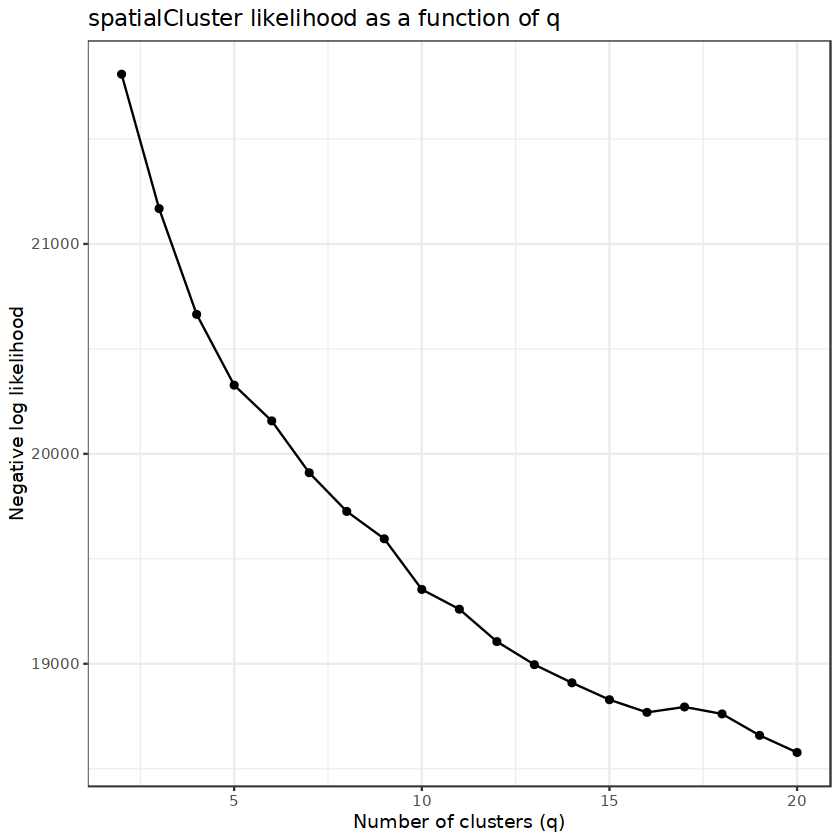

Neighbors were identified for 0 out of 1073 spots.

Fitting model...

Calculating labels using iterations 100 through 3000.



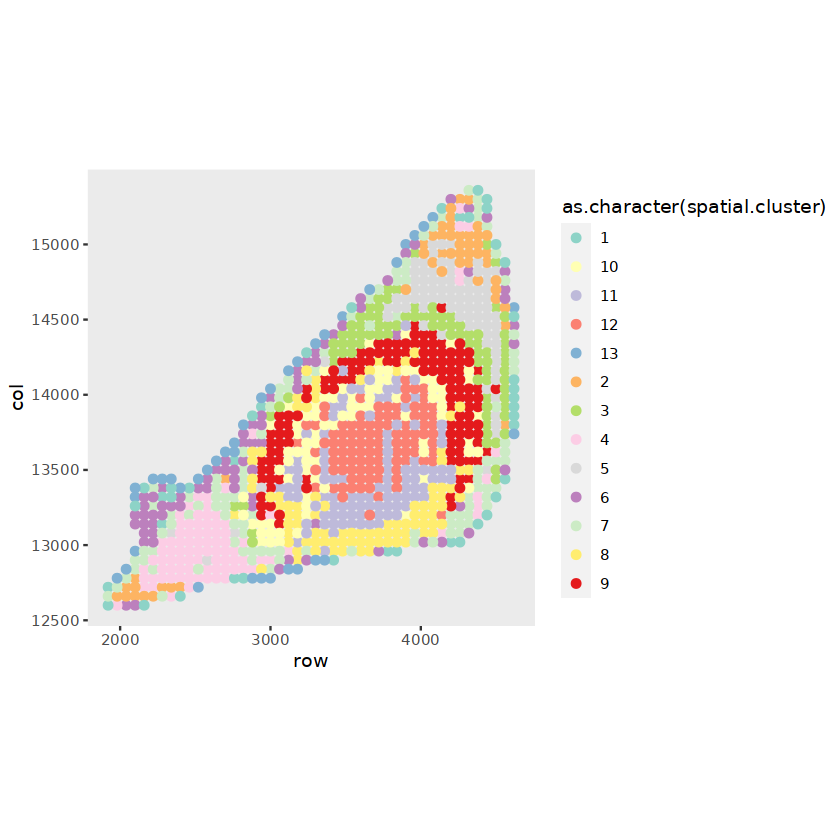

In [ ]:
#pale<-c(brewer.pal(12,"Set3"),brewer.pal(9,"Set1"),brewer.pal(8,"Dark2"),brewer.pal(12,"Paired"))
#temp <- as.data.frame(colData(sce))
#ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
#        scale_colour_discrete(type=pale,na.value="grey")+
#        theme(panel.grid=element_blank())+
#        coord_fixed() 

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from PC to PC_"
Warning message:
"Adding image data that isn't associated with any assays"
Creating h5Seurat file for version 3.1.5.9900

Adding counts for SCT

Adding data for SCT

No variable features found for SCT

Adding feature-level metadata for SCT

Adding cell embeddings for PCA

No loadings for PCA

No projected loadings for PCA

No standard deviations for PCA

No JackStraw data for PCA

Adding cell embeddings for UMAP.UNINTEGRATED

No loadings for UMAP.UNINTEGRATED

No projected loadings for UMAP.UNINTEGRATED

No standard deviations for UMAP.UNINTEGRATED

No JackStraw data for UMAP.UNINTEGRATED

Adding cell embeddings for HARMONY_PCA

No loadings for HARMONY_PCA

No projected loadings for HARMONY_PCA

No standard deviations for HARMONY_PCA

No JackStraw data for HARMONY_PCA

Adding cell embeddings for UMAP.HARMONY

No loadings for UMAP.HARMONY

No projected loadings for

Neighbors were identified for 0 out of 1073 spots.

Fitting model...



In [ ]:
#temp <- as.data.frame(colData(sce))
#ggplot(temp) + geom_point(mapping=aes(x=row, y=col, colour = as.character(spatial.cluster)),size = 2)+
#        scale_colour_discrete(type=pale,na.value="grey")+
#        theme(panel.grid=element_blank())+
#        coord_fixed() 